<a href="https://colab.research.google.com/github/iChetanRaval/DPDzero-Data-Ops-Assignment/blob/main/DPDzero_Data_Ops_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# DPDzero Data Ops Assignment - Collection Calls Pipeline
# Notebook implementing the end-to-end data pipeline for collection call data

# Cell 1: Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [2]:
# Cell 2: Define the Pipeline Class
class CollectionCallsPipeline:
    def __init__(self):
        self.call_logs_df = None
        self.agent_roster_df = None
        self.disposition_summary_df = None
        self.merged_data = None
        self.performance_summary = None

    def ingest_data(self, call_logs_path, agent_roster_path, disposition_summary_path):
        """
        Ingest data from CSV files and perform initial validation
        """
        logger.info("Starting data ingestion...")

        # Read CSV files into pandas DataFrames
        try:
            self.call_logs_df = pd.read_csv("/content/call_logs.csv")
            self.agent_roster_df = pd.read_csv("/content/agent_roster.csv")
            self.disposition_summary_df = pd.read_csv("/content/disposition_summary.csv")

            logger.info(f"Successfully loaded: {call_logs_path}, {agent_roster_path}, {disposition_summary_path}")
        except Exception as e:
            logger.error(f"Error loading data files: {e}")
            raise

        # Validate the ingested data
        self._validate_data()

    def _validate_data(self):
        """
        Validate data for required columns, formats, and highlight issues
        """
        logger.info("Validating data...")

        # Check for required columns
        required_columns = {
            'call_logs_df': ['call_id', 'agent_id', 'org_id', 'installment_id', 'status', 'duration', 'created_ts', 'call_date'],
            'agent_roster_df': ['agent_id', 'users_first_name', 'users_last_name', 'users_office_location', 'org_id'],
            'disposition_summary_df': ['agent_id', 'org_id', 'call_date', 'login_time']
        }

        for df_name, cols in required_columns.items():
            df = getattr(self, df_name)
            missing_cols = [col for col in cols if col not in df.columns]
            if missing_cols:
                logger.warning(f"Missing columns in {df_name}: {missing_cols}")

        # Check for data types and conversion
        try:
            # Convert call_date to datetime if it's not already
            for df_name in ['call_logs_df', 'disposition_summary_df']:
                df = getattr(self, df_name)
                if 'call_date' in df.columns:
                    df['call_date'] = pd.to_datetime(df['call_date'])

            # Check for duplicates
            self._check_duplicates()

            # Check for missing values in key columns
            self._check_missing_values()

        except Exception as e:
            logger.error(f"Error in data validation: {e}")
            raise

    def _check_duplicates(self):
        """Check for duplicate entries in the datasets"""

        # Check for duplicate call_id in call logs
        duplicate_calls = self.call_logs_df.duplicated(subset=['call_id']).sum()
        if duplicate_calls > 0:
            logger.warning(f"Found {duplicate_calls} duplicate call_ids in call logs")

        # Check for duplicate agent_id in agent roster
        duplicate_agents = self.agent_roster_df.duplicated(subset=['agent_id']).sum()
        if duplicate_agents > 0:
            logger.warning(f"Found {duplicate_agents} duplicate agent_ids in agent roster")

    def _check_missing_values(self):
        """Check for missing values in key columns"""

        # Check call logs for missing values in key columns
        call_logs_missing = self.call_logs_df[['call_id', 'agent_id', 'org_id', 'call_date']].isnull().sum()
        if call_logs_missing.sum() > 0:
            logger.warning(f"Missing values in call logs key columns: \n{call_logs_missing[call_logs_missing > 0]}")

        # Check agent roster for missing values in key columns
        agent_roster_missing = self.agent_roster_df[['agent_id', 'org_id']].isnull().sum()
        if agent_roster_missing.sum() > 0:
            logger.warning(f"Missing values in agent roster key columns: \n{agent_roster_missing[agent_roster_missing > 0]}")

        # Check disposition summary for missing values in key columns
        disp_missing = self.disposition_summary_df[['agent_id', 'org_id', 'call_date']].isnull().sum()
        if disp_missing.sum() > 0:
            logger.warning(f"Missing values in disposition summary key columns: \n{disp_missing[disp_missing > 0]}")

    def merge_datasets(self):
        """
        Merge the three datasets while preserving data integrity
        """
        logger.info("Merging datasets...")

        # First, merge call logs with agent roster
        merged_calls_agents = pd.merge(
            self.call_logs_df,
            self.agent_roster_df,
            on=['agent_id', 'org_id'],
            how='left',
            suffixes=('', '_agent')
        )

        # Log any unmatched agents in call logs
        unmatched_agents = merged_calls_agents[merged_calls_agents['users_first_name'].isnull()]['agent_id'].nunique()
        if unmatched_agents > 0:
            logger.warning(f"Found {unmatched_agents} agents in call logs not present in agent roster")

        # Then merge with disposition summary
        self.merged_data = pd.merge(
            merged_calls_agents,
            self.disposition_summary_df,
            on=['agent_id', 'org_id', 'call_date'],
            how='outer',
            suffixes=('', '_disp')
        )

        # Handle mismatches - log them
        calls_without_disp = self.merged_data[
            (self.merged_data['call_id'].notnull()) &
            (self.merged_data['login_time'].isnull())
        ]['agent_id'].nunique()

        disp_without_calls = self.merged_data[
            (self.merged_data['call_id'].isnull()) &
            (self.merged_data['login_time'].notnull())
        ]['agent_id'].nunique()

        logger.info(f"Found {calls_without_disp} agents with calls but no disposition records")
        logger.info(f"Found {disp_without_calls} agents with disposition records but no calls")

        return self.merged_data

    def engineer_features(self):
        """
        Create performance metrics for each agent on each date
        """
        logger.info("Engineering features for performance metrics...")

        # Group by agent_id, org_id, and call_date
        grouped = self.merged_data.groupby(['agent_id', 'org_id', 'call_date']).agg(
            total_calls=pd.NamedAgg(column='call_id', aggfunc='count'),
            unique_loans=pd.NamedAgg(column='installment_id', aggfunc=lambda x: x.nunique()),
            completed_calls=pd.NamedAgg(column='status', aggfunc=lambda x: (x == 'completed').sum()),
            total_duration=pd.NamedAgg(column='duration', aggfunc='sum'),
            users_first_name=pd.NamedAgg(column='users_first_name', aggfunc='first'),
            users_last_name=pd.NamedAgg(column='users_last_name', aggfunc='first'),
            users_office_location=pd.NamedAgg(column='users_office_location', aggfunc='first'),
            login_time=pd.NamedAgg(column='login_time', aggfunc='first')
        ).reset_index()

        # Calculate performance metrics
        grouped['connect_rate'] = (grouped['completed_calls'] / grouped['total_calls']).fillna(0)
        grouped['avg_call_duration_min'] = (grouped['total_duration'] / 60 / grouped['total_calls']).fillna(0)
        grouped['presence'] = grouped['login_time'].notnull().astype(int)

        # Calculate name and ensure we handle missing names
        grouped['agent_name'] = grouped.apply(
            lambda x: f"{x['users_first_name']} {x['users_last_name']}"
            if pd.notnull(x['users_first_name']) and pd.notnull(x['users_last_name'])
            else f"Agent {x['agent_id']}", axis=1
        )

        # Format connect rate as percentage
        grouped['connect_rate_pct'] = (grouped['connect_rate'] * 100).round(2)

        # Select final columns for the performance summary
        self.performance_summary = grouped[[
            'agent_id', 'org_id', 'call_date', 'agent_name', 'users_office_location',
            'total_calls', 'unique_loans', 'completed_calls', 'connect_rate', 'connect_rate_pct',
            'avg_call_duration_min', 'presence'
        ]]

        return self.performance_summary

    def generate_report(self, output_path):
        """
        Save the performance summary and generate a Slack-style report
        """
        if self.performance_summary is None:
            logger.error("No performance summary available. Run engineer_features first.")
            return

        # Save to CSV
        try:
            self.performance_summary.to_csv(output_path, index=False)
            logger.info(f"Performance summary saved to {output_path}")
        except Exception as e:
            logger.error(f"Error saving performance summary: {e}")
            raise

        # Generate Slack-style summary for the most recent date
        most_recent_date = self.performance_summary['call_date'].max()
        daily_data = self.performance_summary[self.performance_summary['call_date'] == most_recent_date]

        # Get metrics for the summary
        active_agents = daily_data[daily_data['presence'] == 1].shape[0]
        avg_duration = daily_data['avg_call_duration_min'].mean().round(1)

        # Find top performer (highest connect rate with at least 10 calls)
        qualified_agents = daily_data[daily_data['total_calls'] >= 10]
        if not qualified_agents.empty:
            top_performer = qualified_agents.loc[qualified_agents['connect_rate'].idxmax()]
            top_performer_name = top_performer['agent_name']
            top_performer_rate = top_performer['connect_rate_pct']
        else:
            top_performer_name = "N/A"
            top_performer_rate = 0

        # Format the summary message
        formatted_date = most_recent_date.strftime('%Y-%m-%d') if isinstance(most_recent_date, pd.Timestamp) else most_recent_date
        summary_message = f"""
        Agent Summary for {formatted_date}
        Top Performer: {top_performer_name} ({top_performer_rate}% connect rate)
        Total Active Agents: {active_agents}
        Average Duration: {avg_duration} min
        """
        logger.info(summary_message)
        return summary_message

    def visualize_performance(self):
        """
        Create visualizations of agent performance metrics
        """
        if self.performance_summary is None:
            logger.error("No performance summary available. Run engineer_features first.")
            return

        # Get the most recent date's data
        most_recent_date = self.performance_summary['call_date'].max()
        daily_data = self.performance_summary[self.performance_summary['call_date'] == most_recent_date].copy()

        # Sort by connect rate for better visualization
        daily_data = daily_data.sort_values('connect_rate', ascending=False)

        # Create a figure with subplots
        fig, axs = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Connect Rate by Agent (Top 10)
        top_10_agents = daily_data.head(10)
        sns.barplot(x='connect_rate_pct', y='agent_name', data=top_10_agents, ax=axs[0, 0])
        axs[0, 0].set_title('Top 10 Agents by Connect Rate')
        axs[0, 0].set_xlabel('Connect Rate (%)')
        axs[0, 0].set_ylabel('Agent Name')

        # 2. Call Volume vs Connect Rate
        scatter = axs[0, 1].scatter(
            daily_data['total_calls'],
            daily_data['connect_rate_pct'],
            alpha=0.7,
            c=daily_data['presence'],
            cmap='viridis',
            s=daily_data['avg_call_duration_min']*5
        )
        axs[0, 1].set_title('Call Volume vs Connect Rate')
        axs[0, 1].set_xlabel('Total Calls')
        axs[0, 1].set_ylabel('Connect Rate (%)')
        legend1 = axs[0, 1].legend(*scatter.legend_elements(),
                                title="Presence")
        axs[0, 1].add_artist(legend1)

        # 3. Average Call Duration by Office Location
        office_avg = daily_data.groupby('users_office_location')['avg_call_duration_min'].mean().reset_index()
        sns.barplot(x='avg_call_duration_min', y='users_office_location', data=office_avg, ax=axs[1, 0])
        axs[1, 0].set_title('Average Call Duration by Office Location')
        axs[1, 0].set_xlabel('Average Call Duration (minutes)')
        axs[1, 0].set_ylabel('Office Location')

        # 4. Distribution of Connect Rates
        sns.histplot(daily_data['connect_rate_pct'], kde=True, ax=axs[1, 1])
        axs[1, 1].set_title('Distribution of Connect Rates')
        axs[1, 1].set_xlabel('Connect Rate (%)')
        axs[1, 1].set_ylabel('Count')

        plt.tight_layout()
        return fig

In [14]:
# Cell 4: Run the Complete Pipeline
def main():
    """Main function to run the pipeline"""

    # Initialize the pipeline
    pipeline = CollectionCallsPipeline()

    # Ingest the data
    pipeline.ingest_data(
        call_logs_path='call_logs.csv',
        agent_roster_path='agent_roster.csv',
        disposition_summary_path='disposition_summary.csv'
    )

    # Explore the data (optional)
    print("\nCall Logs Sample:")
    display(pipeline.call_logs_df.head())

    print("\nAgent Roster Sample:")
    display(pipeline.agent_roster_df.head())

    print("\nDisposition Summary Sample:")
    display(pipeline.disposition_summary_df.head())

    # Merge datasets
    merged_data = pipeline.merge_datasets()
    print("\nMerged Data Sample:")
    display(merged_data.head())

    # Engineer features and calculate metrics
    performance_summary = pipeline.engineer_features()
    print("\nPerformance Summary Sample:")
    display(performance_summary.head())

    # Generate report
    summary_message = pipeline.generate_report('agent_performance_summary.csv')
    print("\nSlack-Style Summary Message:")
    print(summary_message)

    # Visualize the performance (optional)
    fig = pipeline.visualize_performance()
    plt.show()

    # Additional Analysis (optional)
    print("\nPerformance by Office Location:")
    location_summary = performance_summary.groupby('users_office_location').agg({
        'total_calls': 'sum',
        'connect_rate': 'mean',
        'avg_call_duration_min': 'mean',
        'presence': 'mean'
    })
    location_summary['connect_rate_pct'] = (location_summary['connect_rate'] * 100).round(2)
    location_summary['presence_rate_pct'] = (location_summary['presence'] * 100).round(2)
    display(location_summary)

    print("\nDone! Pipeline completed successfully.")


Call Logs Sample:


,call_id,agent_id,org_id,installment_id,status,duration,created_ts,call_date
0,C5333,A020,O2,L1826,completed,5.68,2025-04-28T15:40:00,2025-04-28
1,C3045,A018,O1,L1996,no_answer,14.27,2025-04-28T02:41:00,2025-04-28
2,C5803,A018,O1,L1849,failed,11.01,2025-04-28T19:42:00,2025-04-28
3,C2139,A007,O1,L1046,connected,9.02,2025-04-28T09:52:00,2025-04-28
4,C4814,A003,O1,L1887,completed,2.42,2025-04-28T12:58:00,2025-04-28



Agent Roster Sample:


,agent_id,users_first_name,users_last_name,users_office_location,org_id
0,A001,AgentFirst1,AgentLast1,Bangalore,O1
1,A002,AgentFirst2,AgentLast2,Delhi,O1
2,A003,AgentFirst3,AgentLast3,Mumbai,O1
3,A004,AgentFirst4,AgentLast4,Bangalore,O3
4,A005,AgentFirst5,AgentLast5,Bangalore,O3



Disposition Summary Sample:


...


Merged Data Sample:


,call_id,agent_id,org_id,installment_id,status,duration,created_ts,call_date,users_first_name,users_last_name,users_office_location,login_time
0,C8508,A001,O1,L1636,completed,1.42,2025-04-28T02:30:00,2025-04-28,AgentFirst1,AgentLast1,Bangalore,11:58
1,C4164,A001,O1,L1408,failed,5.44,2025-04-28T09:30:00,2025-04-28,AgentFirst1,AgentLast1,Bangalore,11:58
2,C1757,A001,O1,L1250,no_answer,7.89,2025-04-28T20:51:00,2025-04-28,AgentFirst1,AgentLast1,Bangalore,11:58
3,C2746,A001,O1,L1797,no_answer,1.71,2025-04-28T07:28:00,2025-04-28,AgentFirst1,AgentLast1,Bangalore,11:58
4,C6763,A001,O1,L1305,no_answer,13.95,2025-04-28T14:18:00,2025-04-28,AgentFirst1,AgentLast1,Bangalore,11:58



Performance Summary Sample:


,agent_id,org_id,call_date,agent_name,users_office_location,total_calls,unique_loans,completed_calls,connect_rate,connect_rate_pct,avg_call_duration_min,presence
0,A001,O1,2025-04-28,AgentFirst1 AgentLast1,Bangalore,20,20,2,0.100000,10.00,0.114050,1
1,A002,O1,2025-04-28,AgentFirst2 AgentLast2,Delhi,23,23,3,0.130435,13.04,0.130464,1
2,A003,O1,2025-04-28,AgentFirst3 AgentLast3,Mumbai,21,21,8,0.380952,38.10,0.119492,1
3,A004,O3,2025-04-28,AgentFirst4 AgentLast4,Bangalore,27,27,4,0.148148,14.81,0.134278,1
4,A005,O3,2025-04-28,AgentFirst5 AgentLast5,Bangalore,29,28,4,0.137931,13.79,0.117655,0



Slack-Style Summary Message:

Agent Summary for 2025-04-28
Top Performer: AgentFirst3 AgentLast3 (38.1% connect rate)
Total Active Agents: 17
Average Duration: 0.1 min



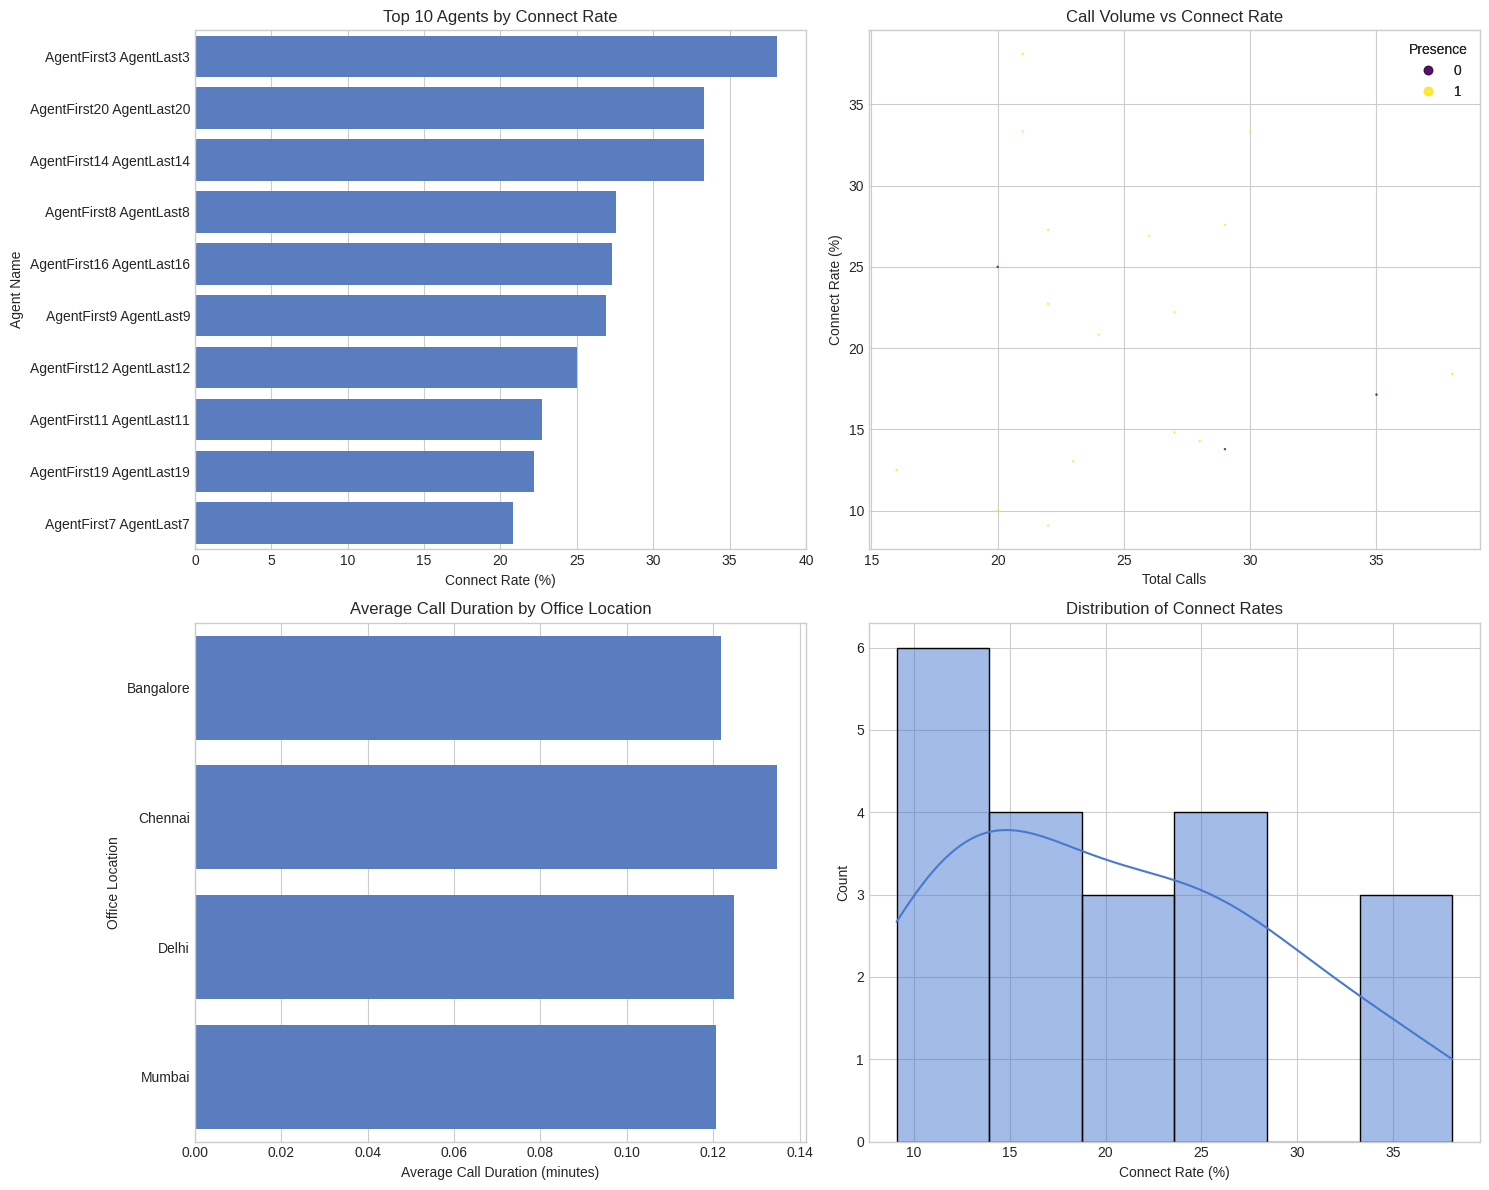


Performance by Office Location:


,total_calls,connect_rate,avg_call_duration_min,presence,connect_rate_pct,presence_rate_pct
users_office_location,,,,,,
Bangalore,161,0.172512,0.121877,0.666667,17.25,66.67
Chennai,113,0.193470,0.134779,0.800000,19.35,80.00
Delhi,88,0.206851,0.124870,1.000000,20.69,100.00
Mumbai,138,0.254872,0.120750,1.000000,25.49,100.00



Done! Pipeline completed successfully.


In [15]:
# Cell 5: Execute the Main Function
if __name__ == "__main__":
    main()